In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [3]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
df.shape

(100000, 9)

In [5]:
df.value_counts("diabetes")

diabetes
0    91500
1     8500
Name: count, dtype: int64

In [6]:
df.value_counts("gender")

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

In [7]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [8]:
df.value_counts("smoking_history")

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [9]:
df.value_counts("age")

age
80.00    5621
51.00    1619
47.00    1574
48.00    1568
53.00    1542
         ... 
0.48       83
1.00       83
0.40       66
0.16       59
0.08       36
Name: count, Length: 102, dtype: int64

In [10]:
diabetic = df[df.diabetes == 1]
nondiabetic = df[df.diabetes == 0]

In [11]:
print(diabetic.shape)
print(nondiabetic.shape)

(8500, 9)
(91500, 9)


In [12]:
nondiab_sample = nondiabetic.sample(n=8500)

In [13]:
print(nondiab_sample.shape)

(8500, 9)


In [14]:
newdiab = pd.concat([nondiab_sample,diabetic],axis=0)

In [15]:
newdiab.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
82621,Female,0.16,0,0,No Info,13.06,6.2,80,0
64974,Male,42.00,0,0,never,27.32,6.2,200,0
80489,Female,42.00,0,0,never,32.87,4.8,126,0
53313,Female,69.00,1,0,never,30.47,3.5,90,0
92132,Female,22.00,0,0,No Info,27.32,5.8,140,0


In [16]:
newdiab.shape

(17000, 9)

In [17]:
newdiab.value_counts('diabetes')

diabetes
0    8500
1    8500
Name: count, dtype: int64

In [18]:
border_values = newdiab.drop(columns = ["gender","smoking_history"],axis=1)
border_values.groupby("diabetes").mean()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
diabetes,,,,,,
0,40.171520,0.061294,0.030118,26.974539,5.404329,133.324000
1,60.946588,0.245647,0.149059,31.988382,6.934953,194.094706


In [19]:
newdiab.value_counts("smoking_history")

smoking_history
never          6284
No Info        4617
former         2318
current        1724
not current    1247
ever            810
Name: count, dtype: int64

In [20]:
newdiab.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,50.559054,0.153471,0.089588,29.481461,6.169641,163.709353,0.500000
std,21.520130,0.360451,0.285599,7.447523,1.279836,56.867961,0.500015
min,0.080000,0.000000,0.000000,10.210000,3.500000,80.000000,0.000000
25%,36.000000,0.000000,0.000000,25.840000,5.700000,130.000000,0.000000
50%,54.000000,0.000000,0.000000,27.320000,6.100000,155.000000,0.500000
75%,67.000000,0.000000,0.000000,32.920000,6.600000,200.000000,1.000000
max,80.000000,1.000000,1.000000,88.720000,9.000000,300.000000,1.000000


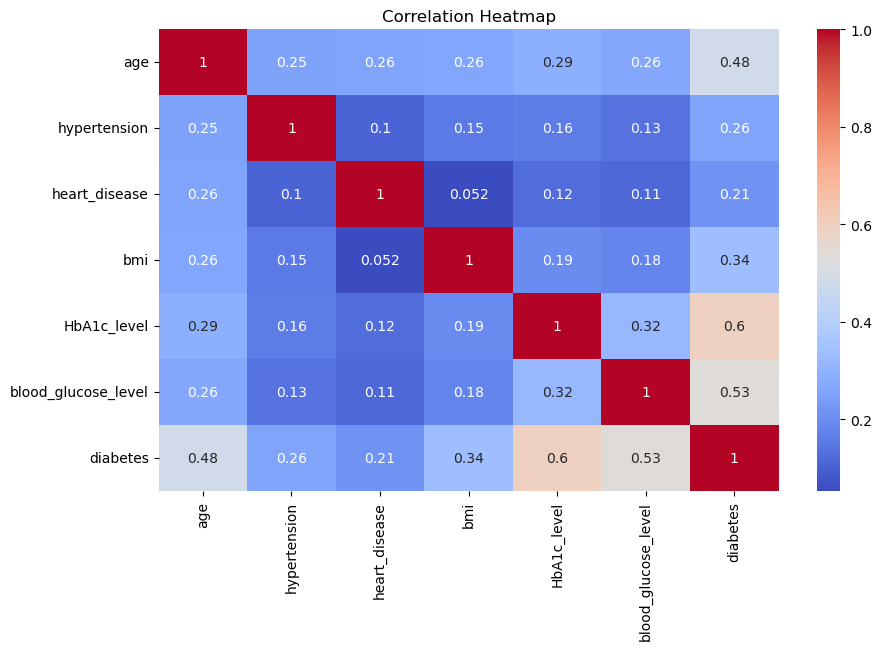

In [21]:
plt.figure(figsize=(10, 6))
correlation = newdiab.corr(numeric_only = True)
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [22]:
newdiab['gender'] = newdiab['gender'].map({'Male':1,'Female':0})

In [23]:
newdiab = pd.get_dummies(newdiab,columns=['smoking_history'])

In [24]:
newdiab.head()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
82621,0.0,0.16,0,0,13.06,6.2,80,0,True,False,False,False,False,False
64974,1.0,42.00,0,0,27.32,6.2,200,0,False,False,False,False,True,False
80489,0.0,42.00,0,0,32.87,4.8,126,0,False,False,False,False,True,False
53313,0.0,69.00,1,0,30.47,3.5,90,0,False,False,False,False,True,False
92132,0.0,22.00,0,0,27.32,5.8,140,0,True,False,False,False,False,False


In [25]:
newdiab = newdiab.dropna(subset=['gender'])

In [26]:
X = newdiab.drop(columns = "diabetes",axis=1)
Y = newdiab["diabetes"]

In [27]:
X

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
82621,0.0,0.16,0,0,13.06,6.2,80,True,False,False,False,False,False
64974,1.0,42.00,0,0,27.32,6.2,200,False,False,False,False,True,False
80489,0.0,42.00,0,0,32.87,4.8,126,False,False,False,False,True,False
53313,0.0,69.00,1,0,30.47,3.5,90,False,False,False,False,True,False
92132,0.0,22.00,0,0,27.32,5.8,140,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99935,0.0,65.00,1,1,33.55,8.2,140,False,False,False,False,True,False
99938,1.0,55.00,0,1,30.42,6.2,300,False,False,False,True,False,False
99957,0.0,61.00,0,0,34.45,6.5,280,True,False,False,False,False,False
99962,0.0,58.00,1,0,38.31,7.0,200,False,False,False,False,True,False


In [28]:
Y

82621    0
64974    0
80489    0
53313    0
92132    0
        ..
99935    1
99938    1
99957    1
99962    1
99979    1
Name: diabetes, Length: 16999, dtype: int64

In [29]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [30]:
scaler = StandardScaler()

In [31]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
classifier = LogisticRegression(solver='liblinear',random_state=42)

In [33]:
classifier.fit(X_train_scaled,Y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [34]:
y_predlog = classifier.predict(X_test_scaled)

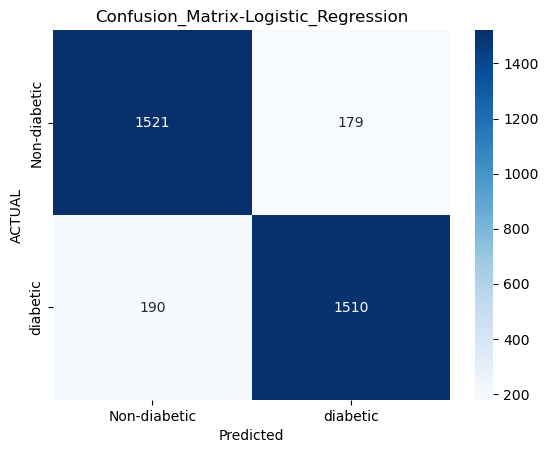

In [35]:
cm = confusion_matrix(Y_test,y_predlog)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Non-diabetic','diabetic'],yticklabels=['Non-diabetic','diabetic'])
plt.title("Confusion_Matrix-Logistic_Regression")
plt.ylabel("ACTUAL")
plt.xlabel("Predicted")
plt.show()

In [36]:
report = classification_report(Y_test,y_predlog)
print(report)

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1700
           1       0.89      0.89      0.89      1700

    accuracy                           0.89      3400
   macro avg       0.89      0.89      0.89      3400
weighted avg       0.89      0.89      0.89      3400



In [37]:
accuracy = accuracy_score(Y_test,y_predlog)

In [38]:
print(f"Accuracy:{accuracy:.2%}")

Accuracy:89.15%


In [39]:
import joblib
joblib.dump(classifier,"diabetes-prediction-model.pkl")
joblib.dump(scaler, "scaler.pkl") 

['scaler.pkl']

In [40]:
newpatient = pd.DataFrame([[1,45,1,0,29,6.5,160,False,False,False,True,False,False]],columns=X_train.columns)
newpatient_scaled = scaler.transform(newpatient)
prediction = classifier.predict(newpatient_scaled)
prediction_probability = classifier.predict_proba(newpatient_scaled)
if prediction[0] == 0:
    print("Patient is non diabetic")
else:
    print("Patient is diabetic")

print(f"Prediction confidence probability: non_diabetic:{prediction_probability[0][0]:.2%},diabetic:{prediction_probability[0][1]:.2%}")

Patient is diabetic
Prediction confidence probability: non_diabetic:22.73%,diabetic:77.27%


In [41]:
#Training the model on svc(support vector classification / support vector machine)
svm_model = SVC(kernel='rbf', probability=True)

svm_model.fit(X_train_scaled, Y_train)

SVC(probability=True)

In [42]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [43]:
svm_accuracy = accuracy_score(Y_test, y_pred_svm)

print(f"SVM Accuracy:{svm_accuracy:.2%}")

SVM Accuracy:89.59%


In [44]:
print("Classification Report (SVM):\n")

print(classification_report(Y_test, y_pred_svm))

Classification Report (SVM):

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1700
           1       0.89      0.91      0.90      1700

    accuracy                           0.90      3400
   macro avg       0.90      0.90      0.90      3400
weighted avg       0.90      0.90      0.90      3400



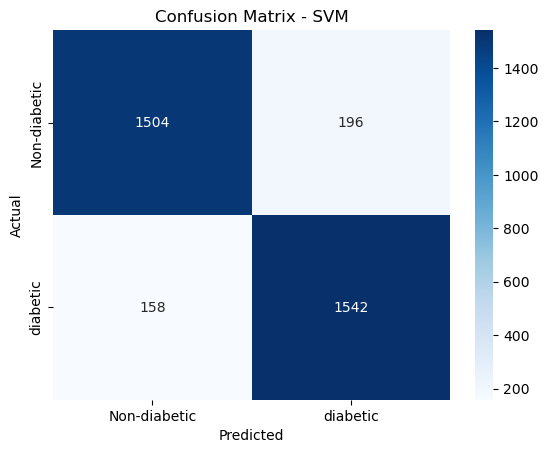

In [45]:
cm_svm = confusion_matrix(Y_test, y_pred_svm)

sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Non-diabetic','diabetic'],
            yticklabels=['Non-diabetic','diabetic'])

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [46]:
new_patient = pd.DataFrame([[1,45,1,0,29,6.5,160,False,False,False,True,False,False]],columns=X_train.columns)

new_patient_scaled = scaler.transform(new_patient)

svm_prediction = svm_model.predict(new_patient_scaled)
svm_probability = svm_model.predict_proba(new_patient_scaled)

if svm_prediction[0] == 0:
    print("The person is NOT diabetic (SVM)")
else:
    print("The person is DIABETIC (SVM)")
    
print("\nConfidence Probability:")
print(f"Non-diabetic: {svm_probability[0][0]*100:.2f}%")
print(f"Diabetic: {svm_probability[0][1]*100:.2f}%")

The person is DIABETIC (SVM)

Confidence Probability:
Non-diabetic: 17.49%
Diabetic: 82.51%


In [47]:
#   Training the Model with Randomforest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [48]:
rf_predictions = rf_model.predict(X_test)

In [49]:
rf_accuracy = accuracy_score(Y_test, rf_predictions)

print(f"Random Forest Accuracy:{rf_accuracy:.2%}")

Random Forest Accuracy:90.59%


In [50]:
print("Classification Report (Random Forest):\n")

print(classification_report(Y_test, rf_predictions))

Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.92      0.89      0.90      1700
           1       0.89      0.92      0.91      1700

    accuracy                           0.91      3400
   macro avg       0.91      0.91      0.91      3400
weighted avg       0.91      0.91      0.91      3400



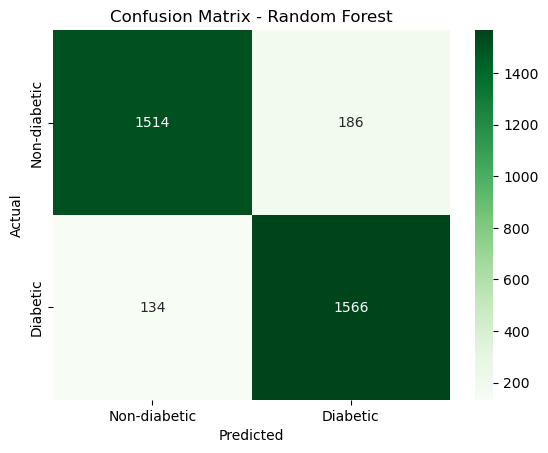

In [51]:
cm_rf = confusion_matrix(Y_test, rf_predictions)

sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Non-diabetic','Diabetic'],
            yticklabels=['Non-diabetic','Diabetic'])

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
new_patient = pd.DataFrame([[1,45,1,0,29,6.5,160,False,False,False,True,False,False]],columns=X_train.columns)

rf_prediction  = rf_model.predict(new_patient)
rf_probability = rf_model.predict_proba(new_patient) 

if rf_prediction[0] == 0:
    print("The person is NOT diabetic (Random Forest)")
else:
    print("The person is DIABETIC (Random Forest)")

print("\nConfidence Probability:")
print(f"Non-diabetic: {rf_probability[0][0]*100:.2f}%")
print(f"Diabetic: {rf_probability[0][1]*100:.2f}%")

The person is NOT diabetic (Random Forest)

Confidence Probability:
Non-diabetic: 53.00%
Diabetic: 47.00%


In [53]:

lr_pred = classifier.predict(X_test_scaled)
svm_pred = svm_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)


lr_acc = accuracy_score(Y_test, lr_pred)
svm_acc = accuracy_score(Y_test, svm_pred)
rf_acc = accuracy_score(Y_test, rf_pred)

print("Model Accuracy Comparison\n")

print(f"Logistic Regression Accuracy : {lr_acc*100:.2f}%")
print(f"SVM Accuracy                 : {svm_acc*100:.2f}%")
print(f"Random Forest Accuracy       : {rf_acc*100:.2f}%")


best_model = max(
    [("Logistic Regression", lr_acc),
     ("SVM", svm_acc),
     ("Random Forest", rf_acc)],
    key=lambda x: x[1]
)

print(f"\nBest Performing Model: {best_model[0]} ({best_model[1]*100:.2f}%)")

Model Accuracy Comparison

Logistic Regression Accuracy : 89.15%
SVM Accuracy                 : 89.59%
Random Forest Accuracy       : 90.59%

Best Performing Model: Random Forest (90.59%)


In [54]:
joblib.dump(svm_model, "svm-model.pkl")

['svm-model.pkl']

In [55]:
joblib.dump(rf_model, "random-forest-model.pkl")

['random-forest-model.pkl']